In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools
from itertools import combinations, permutations
from typing import Dict, Tuple, List
import random
import pulp
import time
import math

In [2]:
import pulp
from pulp import LpProblem, LpVariable, lpSum, LpMaximize, LpBinary, LpStatus, value
from collections import defaultdict

def solver_for_opt_network(network):
    
    n = network.n_players
    allowed_graph = network.allowed_graph
    neighbor_limits = network.neighbor_limits
    payoffs = network.payoffs
    model = LpProblem("BIP1", LpMaximize)

    y = {}
    for (i, j) in allowed_graph:
        y[i, j] = LpVariable(f"y_{i}_{j}", cat=LpBinary)
    

    model += lpSum(payoffs[(i, j)] * y[i, j] for (i, j) in allowed_graph)
    
    for i in range(1, n+1):
        model += lpSum(y[min(i, j), max(i, j)] for j in range(1, n+1) if (min(i, j), max(i, j)) in allowed_graph) <= neighbor_limits[i]

    model.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=300))
    
    opt_edges = []
    opt_neighbors = {i: [] for i in range(1, n + 1)}
    for (i, j) in allowed_graph:
        if value(y[i ,j]) == 1:
            opt_edges.append((i , j))
            opt_neighbors[i].append(j)
            opt_neighbors[j].append(i)
            
    if model.status == 1:
        return {
            'opt_value': value(model.objective),
            'opt_edges': opt_edges,
            'neighbors_dict': dict(sorted(opt_neighbors.items()))
        }
    
    return "Error"

In [ ]:
import pulp
from pulp import LpProblem, LpVariable, lpSum, LpMaximize, LpBinary, LpStatus, value
from collections import defaultdict

def solver_for_v_2(network, coalition):
    
    allowed_graph = network.allowed_graph
    neighbor_limits = network.neighbor_limits
    payoffs = network.payoffs
    opt_neighbors = network.opt_neighbors
    bimatrix_games = network.bimatrix_games
    
    model = LpProblem("BIP2", LpMaximize)

    z = {}
    
    for i in coalition:
        for j in set(opt_neighbors[i]).difference(coalition):
            z[i, j] = LpVariable(f"z_{i}_{j}", cat=LpBinary)
        for j in coalition:
            if (i, j) in allowed_graph:
                z[i, j] = LpVariable(f"z_{i}_{j}", cat=LpBinary)
                z[j, i] = LpVariable(f"z_{j}_{i}", cat=LpBinary)

    model += lpSum(
        payoffs[(i, j)] * z[i, j] 
        for (i, j) in allowed_graph if {i, j}.issubset(coalition)
    ) + lpSum(
        network.max_min(bimatrix_games[(i,k)][0]) * z[i, k]
        for i in coalition 
        for k in set(opt_neighbors[i]).difference(coalition)
        if i < k
    ) + lpSum(
        network.max_min(bimatrix_games[(k,i)][1]) * z[i, k]
        for i in coalition 
        for k in set(opt_neighbors[i]).difference(coalition)
        if i > k
    )

    for (i, j) in allowed_graph:
        if {i, j}.issubset(coalition):
            model += (z[i, j] == z[j ,i])
        
    for i in coalition:
        model += (lpSum(z[i, j] for j in set(opt_neighbors[i]).difference(coalition))
                  + lpSum(z[i, j] for j in coalition if (min(i, j), max(i, j)) in allowed_graph) ) <= neighbor_limits[i]
    
   
    model.solve(pulp.PULP_CBC_CMD(msg=1, timeLimit=300))

    new_edges = []
    v = 0
    for (i, j) in z:
        if z[i, j].varValue == 1:
            new_edges += [(i, j)]
            if i < j:
                if {i, j}.issubset(coalition):
                    v += 0.5 * payoffs[(i, j)]
                else:
                    v += network.max_min(bimatrix_games[(i,j)][0])
            else:
                if {i, j}.issubset(coalition):
                    v += 0.5 * payoffs[(j, i)]
                else:
                    v += network.max_min(bimatrix_games[(j, i)][1])

    new_edges = [(x, y) for (x, y) in new_edges if x < y]
    edges_out_of_coalition = [(i, j) for (i, j) in network.opt_edges if i not in coalition and j not in coalition]
    all_edges = list(set(edges_out_of_coalition + new_edges))
    if model.status == 1:
         return {
             "new_edges": new_edges,
             "all_edges": all_edges,
             "v": v}

In [ ]:
class CreateNetwork:
    def __init__(self, n: int, bimatrix_games: Dict[Tuple[int, int], Tuple[List[List[int]], List[List[int]]]], 
                 neighbor_limits: Dict[int, int], allowed_neighbors: Dict[int, List[int]]):
        self.n_players = n
        
        self.bimatrix_games = bimatrix_games

        self.neighbor_limits = neighbor_limits
        self.allowed_neighbors = allowed_neighbors

        self.allowed_graph = set()
 
        self.graph = nx.Graph()
        self.graph.add_nodes_from(range(1, self.n_players+1))

        self.payoffs = {}
        self.total_weight = 0

        self.precompute_weights()

        self.opt_value, self.opt_edges, self.opt_neighbors = solver_for_opt_network(self).values()

         
        # self.find_vector_shapley(self.n_players)

    def find_max_sum(self, a, b): # максимальная сумма элементов матрицей выигрышей 
        a = np.array(a)
        b = np.array(b)
        return np.max(a + b.T)

    def precompute_weights(self) -> None: # заполнение edge_payoffs
        for (i, j), (A, B) in self.bimatrix_games.items():
            if j in self.allowed_neighbors[i] and i in self.allowed_neighbors[j]:
                payoff = self.find_max_sum(A, B)
                self.payoffs[(i, j)] = payoff

                self.allowed_graph.add((i, j))

    def max_min(self, matrix) -> int:
        rows_min = []
        for s in range(len(matrix)):
            rows_min.append(min(matrix[s]))
        return max(rows_min)

    def find_v_1(self, coalition):
        v = 0
        if len(coalition) == 0:
            return 0
        for i in coalition:
            for j in self.opt_neighbors[i]:
                if j in coalition:
                    if i < j:
                        max_sum = self.find_max_sum(
                            self.bimatrix_games[(i, j)][0], 
                            self.bimatrix_games[(i, j)][1]  
                        )
                        v = v + float(max_sum)
                else:
                    if i < j:
                        v += self.max_min(self.bimatrix_games[(i,j)][0])
                    else:
                        v += self.max_min(self.bimatrix_games[(j, i)][1])
        return v

    # def find_vector_shapley(self) -> None:
    #     for i in range(1, self.n_players):
    #         for s in range(1, self.n_players + 1):
    #             multi_1 = (math.factorial(s-1) * math.factorial(self.n_players - s)) / math.factorial(self.n_players)
    #             multi_2 = 0
    #             multi_3 = 0
    #             for j in self.opt_neighbors[i]:
    #                 if s > 1:
    #                     multi_2 += self.find_max_sum(self.bimatrix_games[(min(i,j), max(i, j))][0], self.bimatrix_games[(min(i,j), max(i, j))][1])
    #                 if i < j:
    #                     multi_3 += self.max_min(self.bimatrix_games[(i,j)][0])
    #                 else:
    #                     multi_3 += self.max_min(self.bimatrix_games[(j, i)][1])
    #             if s > 1:
    #                 multi_2 = 0.5 * multi_2 * math.comb(self.n_players - 2, s - 2)
    #             if s < self.n_players:
    #                 multi_3 = multi_3 * math.comb(self.n_players - 2, self.n_players - s - 1)
    #             self.shapley[i-1] = multi_1 * (multi_2 + multi_3)
                
    
    def find_vector_shapley_1(self, n):
        shapley = np.zeros(n)
        players = range(1, n+1)
        all_coalitions = [comb for i in range(1, n + 1) for comb in itertools.combinations(players, i)]
        for coalition in all_coalitions:
            for i in coalition:
                s = len(coalition)
                coalition_without_i = tuple(x for x in coalition if x != i)
                shapley[i-1] += ( ( math.factorial(s - 1)*math.factorial(n - s) ) / math.factorial(n) ) * ( self.find_v_1(coalition) - self.find_v_1(coalition_without_i) )   
        return shapley


    def find_vector_shapley_2(self, n):
        shapley = np.zeros(n)
        players = range(1, n+1)
        all_coalitions = [comb for i in range(1, n + 1) for comb in itertools.combinations(players, i)]
        for coalition in all_coalitions:
            for i in coalition:
                s = len(coalition)
                coalition_without_i = tuple(x for x in coalition if x != i)
                shapley[i-1] += ( ( math.factorial(s - 1)*math.factorial(n - s) ) / math.factorial(n) ) * ( solver_for_v_2(self, coalition)["v"] - solver_for_v_2(self, coalition_without_i)["v"] )   
        return shapley

    def drawing(self, edges) -> None:

        self.graph.clear_edges()
        self.graph.add_edges_from(edges)

        params = optimized_graph_parameters(self.graph)

        pos = params['pos']
        plt.figure(figsize=params['figsize'])

        nx.draw_networkx_nodes(self.graph, pos, node_size=params['node_size'], node_color='lightblue', alpha=params['node_alpha'])
        
        nx.draw_networkx_labels(self.graph, pos, font_size=params['font_size'])
  
        nx.draw_networkx_edges(self.graph, pos, width=params['edge_width'], edge_color='gray', alpha=params['edge_alpha'])

        plt.axis("off")
        plt.show()


In [ ]:
def optimized_graph_parameters(G, scale_multiplier=1.5): # параметры рисунка графа для различного числа узлов
    n = G.number_of_nodes()
    
    if n <= 5:
        k_val = 0.3
        iterations = 15
        scale = 0.8
        figsize = (8, 6)
        node_size = 800
        edge_width = 2.0
        font_size = 12
        node_alpha = 0.9
        edge_alpha = 0.8
    elif n <= 15:
        k_val = 0.6
        iterations = 25
        scale = 1.0
        figsize = (10, 8)
        node_size = 600
        edge_width = 1.5
        font_size = 11
        node_alpha = 0.85
        edge_alpha = 0.7
    elif n <= 30:
        k_val = 0.9
        iterations = 35
        scale = 1.3
        figsize = (12, 10)
        node_size = 400
        edge_width = 1.2
        font_size = 10
        node_alpha = 0.8
        edge_alpha = 0.6
    elif n <= 60:
        k_val = 1.2
        iterations = 50
        scale = 1.6
        figsize = (14, 12)
        node_size = 300
        edge_width = 1.0
        font_size = 9
        node_alpha = 0.75
        edge_alpha = 0.5
    elif n <= 90:
        k_val = 1.4
        iterations = 70
        scale = 1.8
        figsize = (16, 14)
        node_size = 250
        edge_width = 0.8
        font_size = 8
        node_alpha = 0.7
        edge_alpha = 0.45
    elif n <= 120:
        k_val = 1.6
        iterations = 90
        scale = 2.0
        figsize = (18, 16)
        node_size = 200
        edge_width = 0.7
        font_size = 7
        node_alpha = 0.65
        edge_alpha = 0.4
    elif n <= 160:
        k_val = 1.8
        iterations = 110
        scale = 2.2
        figsize = (20, 18)
        node_size = 150
        edge_width = 0.6
        font_size = 6
        node_alpha = 0.6
        edge_alpha = 0.35
    elif n <= 200:
        k_val = 2.0
        iterations = 130
        scale = 2.4
        figsize = (22, 20)
        node_size = 120
        edge_width = 0.5
        font_size = 5
        node_alpha = 0.55
        edge_alpha = 0.3
    else:
        k_val = 2.5
        iterations = 150
        scale = 2.8
        figsize = (24, 22)
        node_size = 100
        edge_width = 0.4
        font_size = 4
        node_alpha = 0.5
        edge_alpha = 0.25
        
    pos = nx.spring_layout(G,
        k=k_val * scale_multiplier,
        iterations=iterations,
        threshold=1e-4,
        scale=scale * scale_multiplier,
        seed=42
    )

    return {
        'pos': pos,
        'figsize': figsize,
        'node_size': node_size,
        'edge_width': edge_width,
        'font_size': font_size,
        'node_alpha': node_alpha,
        'edge_alpha': edge_alpha
    }

In [ ]:
def сreate_bimatrix_games(n, m_strategy, k_strategy, lower_limit: int, upper_limit: int):
    pairs = list(combinations(range(1, n+1), 2))
    np.random.seed(52)
    bimatrix_games = {}
        
    for pair in pairs:
        key = pair
        payoff1 = np.random.randint(lower_limit, upper_limit, (m_strategy, k_strategy)).tolist()
        payoff2 = np.random.randint(lower_limit, upper_limit, (k_strategy, m_strategy)).tolist()
        bimatrix_games[key] = (payoff1, payoff2)
    return bimatrix_games

In [7]:
def сreate_two_constraints(n):
    neighbor_limits={}
    allowed_neighbors={}
    
    for key in range(1, n + 1):
        neighbor_limits[key]=random.randint(1, n - 1)
        
        possible_values = [i for i in range(1, n + 1) if i != key]
        list_size = random.randint(1, n - 1)
        random_values = random.sample(possible_values, list_size)
        random_values.sort()
        allowed_neighbors[key] = random_values
    return neighbor_limits, allowed_neighbors   

In [8]:
def print_dict_matrices_with_names(dictionary, m, k) -> None: # красивый вывод биматричных игр
    biggest_len = max(m ,k)
    for key, matrices in dictionary.items():
    
        name1 = f"A{key}"
        name2 = f"A{key[::-1]}"
        
        for i in range(biggest_len):
            if m == biggest_len:
                if i == m // 2:
                    print(f"{name1} = ", end='')
                    print(*matrices[0][i], end='  ')
                    if i < k:
                        if i == k // 2:
                            print(f"{name2} = ", end='')
                            print(*matrices[1][i])
                        else:
                            print(' '*(len(name2)+2), *matrices[1][i]) 
                    else:
                        print()
                else:
                    print(' '*(len(name1)+2), *matrices[0][i], end = '  ')
                    if i < k:
                        if i == k // 2:
                            print(f"{name2} = ", end='')
                            print(*matrices[1][i])
                        else:
                            print(' '*(len(name2)+2), *matrices[1][i]) 
                    else:
                        print()
            else:
                if i < m:
                    if i == m // 2:
                        print(f"{name1} = ", end='')
                        print(*matrices[0][i], end='  ')
                    else:
                        print(' '*(len(name1)+2), *matrices[0][i], end = '  ')
                    if i == k // 2:
                        print(f"{name2} = ", end='')
                        print(*matrices[1][i])
                    else:
                        print(' '*(len(name2)+2), *matrices[1][i])                             
                else:
                    if i == k // 2:
                        print(' '*(len(name1)+2*k+3), f"{name2} = ", end = '')
                        print(*matrices[1][i])
                    else:
                        print(' '*(len(name1)+len(name2)+2*k+6), *matrices[1][i])
                
        print()

Биматричные игры:
          6 8            4 4 2
A(1, 2) = 7 8  A(2, 1) = 4 2 6
          1 6  

          2 1            5 7 8
A(1, 3) = 1 7  A(3, 1) = 8 8 5
          7 8  

          3 6            6 3 7
A(1, 4) = 5 1  A(4, 1) = 7 6 1
          2 3  

          7 9            2 6 9
A(1, 5) = 2 8  A(5, 1) = 5 1 7
          2 7  

          8 4            2 8 7
A(1, 6) = 8 1  A(6, 1) = 8 5 8
          1 6  

          1 2            7 4 2
A(1, 7) = 6 2  A(7, 1) = 9 8 7
          5 1  

          5 7            1 8 3
A(1, 8) = 6 9  A(8, 1) = 1 3 3
          2 1  

          4 5            1 4 4
A(1, 9) = 8 1  A(9, 1) = 5 6 2
          2 1  

           5 2             3 4 2
A(1, 10) = 1 1  A(10, 1) = 7 7 9
           3 8  

          6 1            7 7 5
A(2, 3) = 9 9  A(3, 2) = 4 1 6
          3 7  

          1 2            6 1 1
A(2, 4) = 1 7  A(4, 2) = 6 6 7
          7 3  

          7 9            5 4 1
A(2, 5) = 6 3  A(5, 2) = 2 7 9
          2 4  

          8 2            5 5 

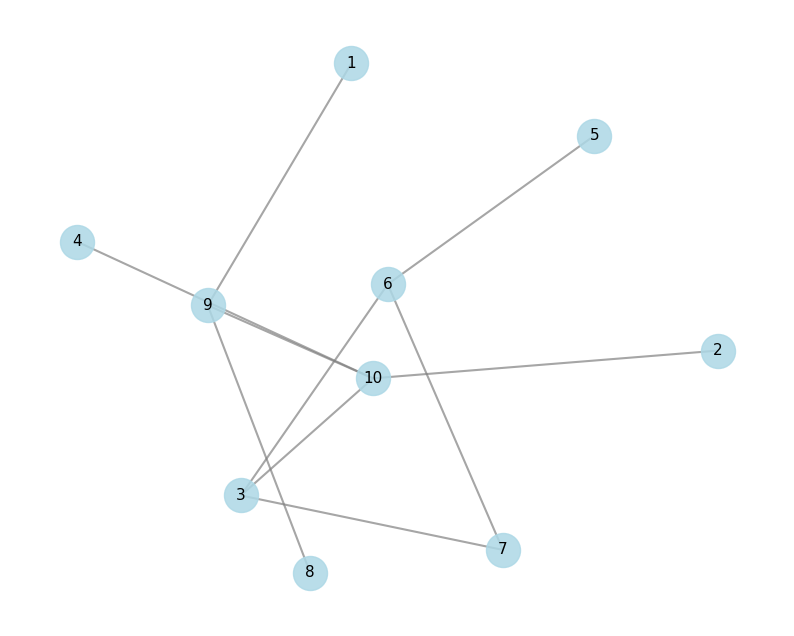

Харатеристическая функция для 5 произвольных коалиций:
v([6]) = 19
v([1, 2, 3, 4, 6, 7, 8, 9, 10]) = 143.0
v([4, 5, 6, 7, 9]) = 62.0
v([2]) = 7
v([1, 2, 3, 4, 5, 6, 7]) = 82.0

Пример модификации характеристической функции:
BIP2:
MAXIMIZE
4*z_1_9 + 7*z_2_10 + 13*z_2_4 + 7*z_3_10 + 4*z_3_6 + 6*z_3_7 + 4*z_4_10 + 0.0
SUBJECT TO
_C1: z_2_4 - z_4_2 = 0

_C2: z_1_9 <= 6

_C3: z_2_10 + z_2_4 <= 1

_C4: z_3_10 + z_3_6 + z_3_7 <= 9

_C5: z_4_10 + z_4_2 <= 7

VARIABLES
0 <= z_1_9 <= 1 Integer
0 <= z_2_10 <= 1 Integer
0 <= z_2_4 <= 1 Integer
0 <= z_3_10 <= 1 Integer
0 <= z_3_6 <= 1 Integer
0 <= z_3_7 <= 1 Integer
0 <= z_4_10 <= 1 Integer
0 <= z_4_2 <= 1 Integer

S: {1, 2, 3, 4}
v({1, 2, 3, 4}) = 38.0
Граф:


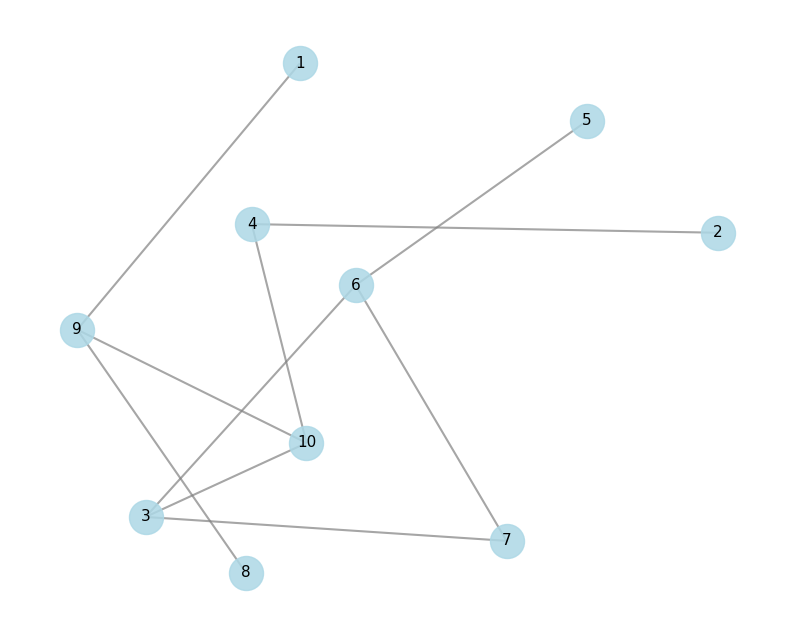


Вектор Шепли с использованием первой характеристической функции:
[ 7.  10.5 24.5  9.5  8.5 26.  13.   7.  21.5 26.5]
Программа работала: 21.1478 секунд


In [16]:
def main():
    # random.seed(30)
    n = 10
    m = 3
    k = 2
    bimatrix_games = сreate_bimatrix_games(n, m, k, 1, 10)
  
    neighbor_limits, allowed_neighbors = сreate_two_constraints(n)

    network = CreateNetwork(n, bimatrix_games, neighbor_limits, allowed_neighbors)

    print("Биматричные игры:")
    print_dict_matrices_with_names(bimatrix_games, m, k)

    print("Множества допустимых игроков")
    print(network.allowed_neighbors, "\n")

    print("Максимальные количества связей:")
    print(network.neighbor_limits, "\n")

    print(network.allowed_graph)

    print("Множество ребер в оптимальном графе:")
    print(network.opt_neighbors, "\n")

    print("Значение характеристической функции гранд-коалиции в оптимальном графе:")
    print(f"v(N) = {network.opt_value} \n")

    print("Граф оптимальной сети:")
    network.drawing(network.opt_edges)

    print("Харатеристическая функция для 5 произвольных коалиций:")
    for i in range(5):
        possible_values = [i for i in range(1, n + 1)]
        list_size = random.randint(0, n)
        random_coalition = random.sample(possible_values, list_size)
        random_coalition.sort()
        v = network.find_v_1(random_coalition)
        print(f"v({random_coalition}) = {v}")
        
    print()

    print("Пример модификации характеристической функции:")
    coalition = {1, 2, 3, 4}
    coalition_edges, all_edges, v = solver_for_v_2(network, coalition).values()
    print(f"S: {coalition}")
    print(f"v({coalition}) = {v}")
    print("Граф:")
    network.drawing(all_edges)

    print()

    print("Вектор Шепли с использованием первой характеристической функции:")
    print(network.find_vector_shapley_1(n))
    # print("Вектор Шепли с использованием модифицированной характеристической функции:")
    # print(network.find_vector_shapley_2(n))

if __name__ == "__main__":
    start_time = time.time()
    
    main()
        
    end_time = time.time()
    execution_time = end_time - start_time
    print(f"Программа работала: {execution_time:.4f} секунд") 

In [ ]:
def get_params():
    return n